# Import needed modules

In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


# **Data Preprocessing**

### **Read data and store it in dataframe**

In [2]:
import os
import pandas as pd

train_data_dir = '/Users/anshikalohan/Downloads/skin_dataset/train'

filepaths = []
labels = []

folds = os.listdir(train_data_dir)

for fold in folds:
    foldpath = os.path.join(train_data_dir, fold)
    
    
    if not os.path.isdir(foldpath):
        continue

    filelist = os.listdir(foldpath)
    
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

# Create dataframe
train_df = pd.DataFrame({
    'filepaths': filepaths,
    'labels': labels
})

print(train_df.head())

                                           filepaths     labels
0  /Users/anshikalohan/Downloads/skin_dataset/tra...  malignant
1  /Users/anshikalohan/Downloads/skin_dataset/tra...  malignant
2  /Users/anshikalohan/Downloads/skin_dataset/tra...  malignant
3  /Users/anshikalohan/Downloads/skin_dataset/tra...  malignant
4  /Users/anshikalohan/Downloads/skin_dataset/tra...  malignant


In [3]:
train_df

,filepaths,labels
0,/Users/anshikalohan/Downloads/skin_dataset/tra...,malignant
1,/Users/anshikalohan/Downloads/skin_dataset/tra...,malignant
2,/Users/anshikalohan/Downloads/skin_dataset/tra...,malignant
3,/Users/anshikalohan/Downloads/skin_dataset/tra...,malignant
4,/Users/anshikalohan/Downloads/skin_dataset/tra...,malignant
...,...,...
2632,/Users/anshikalohan/Downloads/skin_dataset/tra...,benign
2633,/Users/anshikalohan/Downloads/skin_dataset/tra...,benign
2634,/Users/anshikalohan/Downloads/skin_dataset/tra...,benign
2635,/Users/anshikalohan/Downloads/skin_dataset/tra...,benign


In [4]:
# Generate data paths with labels
test_data_dir = '/Users/anshikalohan/Downloads/skin_dataset/test'
filepaths = []
labels = []

folds = os.listdir(test_data_dir)
for fold in folds:
    foldpath = os.path.join(test_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
test_df = pd.concat([Fseries, Lseries], axis= 1)

### **Create image data generator**

In [5]:
# crobed image size
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 2637 validated image filenames belonging to 2 classes.
Found 660 validated image filenames belonging to 2 classes.


### **Show sample from train data**

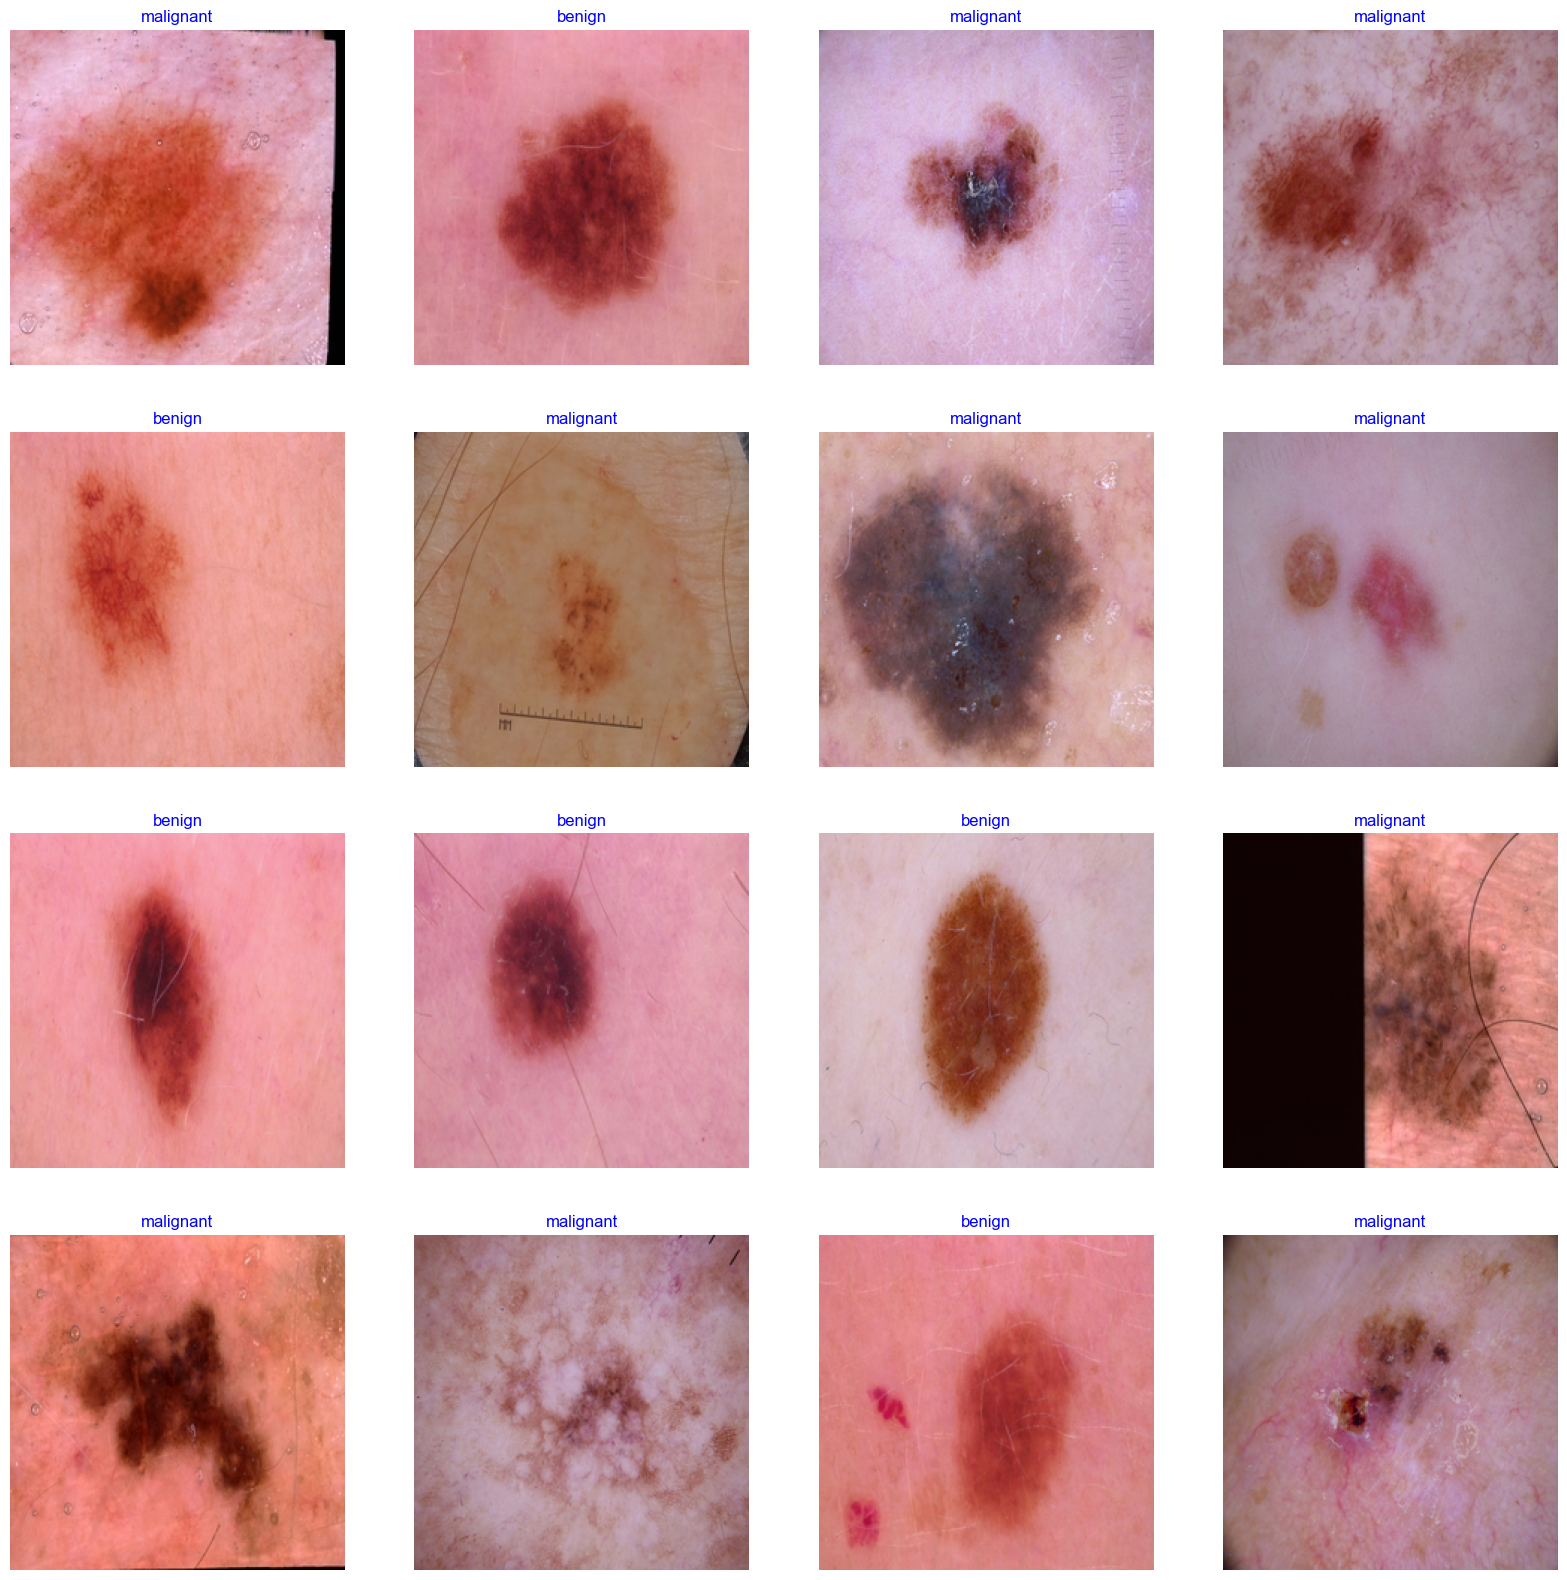

In [6]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

# **Model Structure**

#### **Generic Model Creation**

In [7]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can built on pretrained model such as :  efficientnet, VGG , Resnet )
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')
base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, activation='relu',
      kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,141 (16.72 MB)

 Trainable params: 331,010 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

#### **Train model**

In [8]:
epochs = 20

history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= test_gen, 
                    validation_steps= None, shuffle= True)

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.7349 - loss: 0.6940 - val_accuracy: 0.8000 - val_loss: 0.5139
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 185ms/step - accuracy: 0.7979 - loss: 0.5417 - val_accuracy: 0.8303 - val_loss: 0.4410
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 31s 189ms/step - accuracy: 0.8195 - loss: 0.4937 - val_accuracy: 0.8394 - val_loss: 0.4305
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 31s 190ms/step - accuracy: 0.8320 - loss: 0.4428 - val_accuracy: 0.8379 - val_loss: 0.4199
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.8347 - loss: 0.4270 - val_accuracy: 0.8455 - val_loss: 0.4417
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.8639 - loss: 0.3685 - val_accuracy: 0.8545 - val_loss: 0.4273
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 298ms/step - accuracy: 0.8521 - loss: 0.3711 - val_accuracy: 0.8515 - val_loss: 0.4099
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 51s 310ms/step - accuracy: 0.8650 - loss: 0

#### **Display model performance**

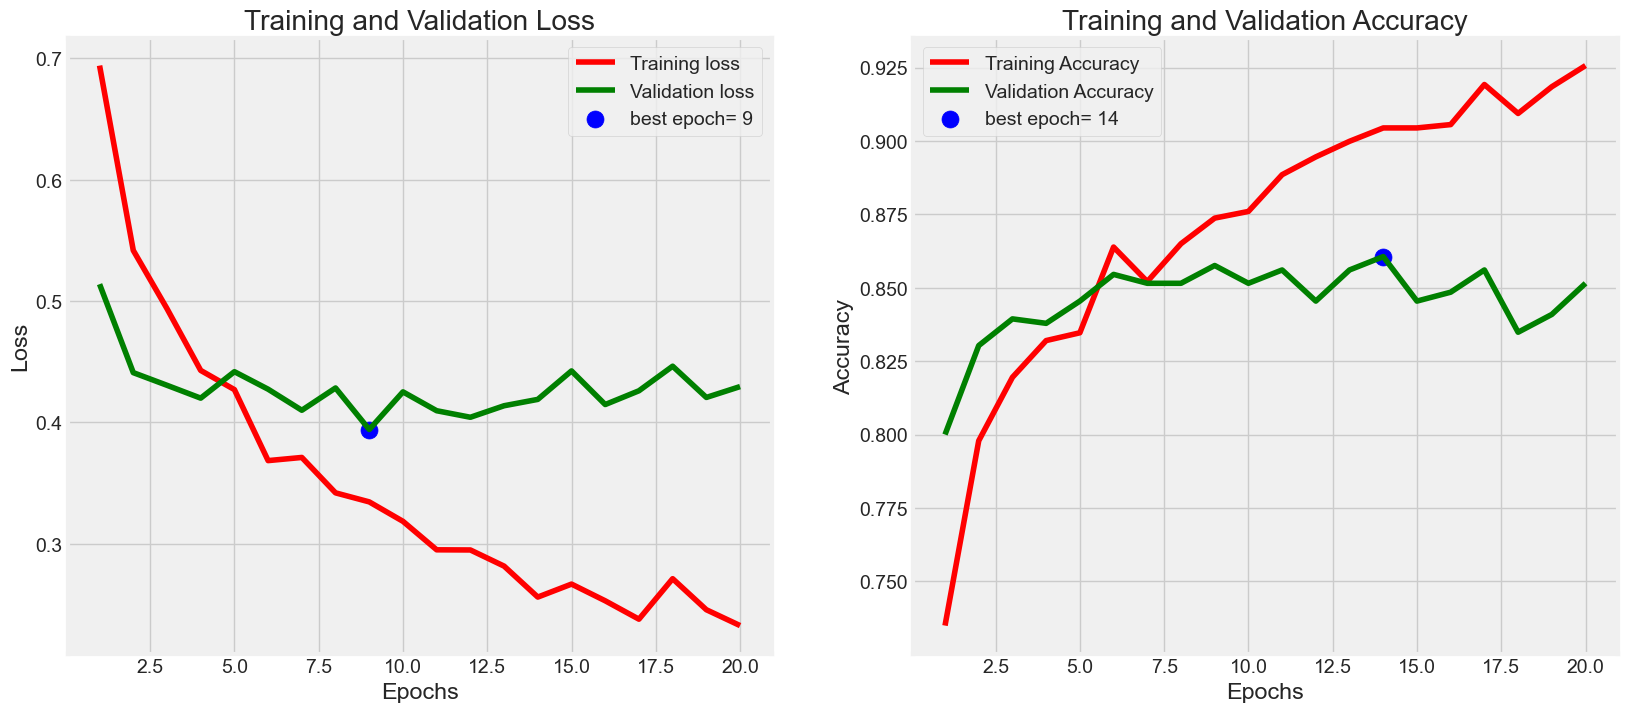

In [9]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

# **Evaluate model**

In [10]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.9750 - loss: 0.1278
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.8750 - loss: 0.3870
Train Loss:  0.12780913710594177
Train Accuracy:  0.9750000238418579
--------------------
Test Loss:  0.3870384991168976
Test Accuracy:  0.875


# **Get Predictions**

In [12]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step


#### **Confusion Matrics and Classification Report**

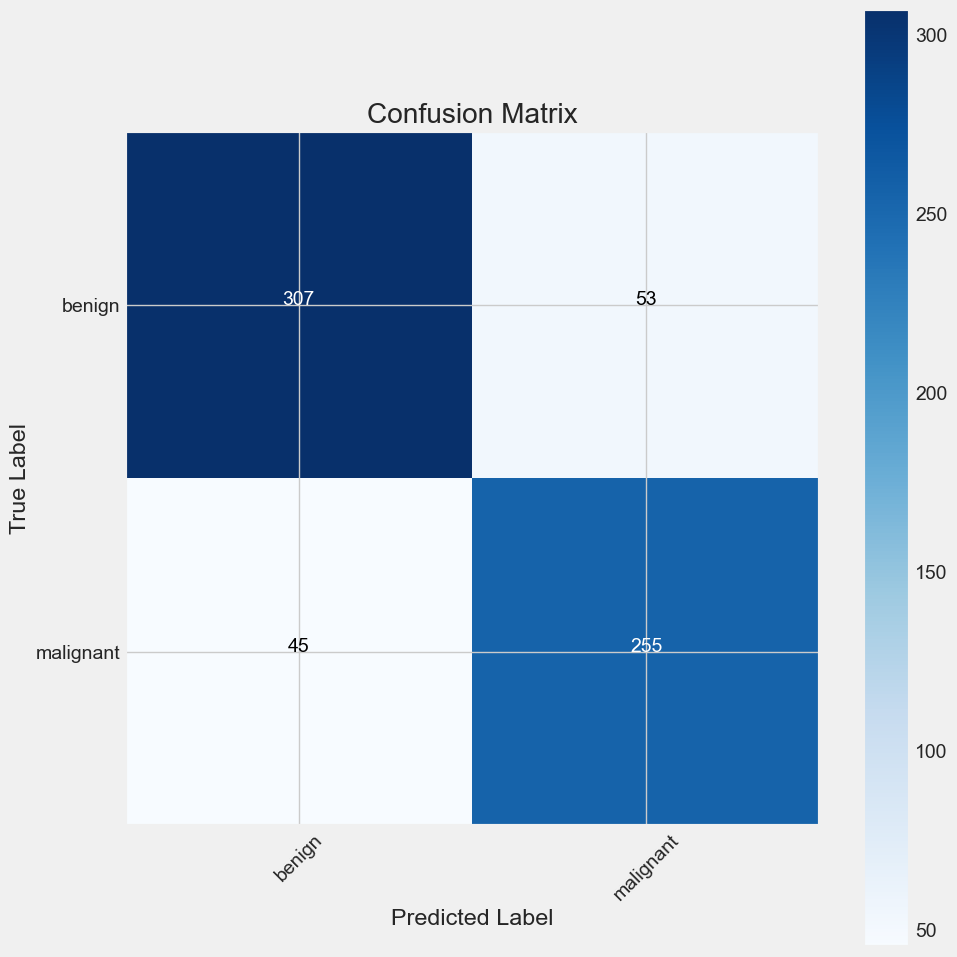

In [13]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [14]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

      benign       0.87      0.85      0.86       360
   malignant       0.83      0.85      0.84       300

    accuracy                           0.85       660
   macro avg       0.85      0.85      0.85       660
weighted avg       0.85      0.85      0.85       660



#### **Save model**

In [15]:
#Save the model
model.save('Skin Cancer.h5')